# Task 2: Credit Risk Prediction
## DevelopersHub Corporation – Data Science & Analytics Internship

### Problem Statement
Banks and financial institutions need to assess the risk of loan default before approving loans. This task builds a machine learning model to **predict whether a loan applicant is likely to default**, enabling smarter lending decisions.

### Dataset Description
- **Dataset**: Loan Prediction Dataset (similar to Kaggle version)
- **Rows**: 614 | **Columns**: 13
- **Target Variable**: `Loan_Status` (Y = Approved, N = Rejected)
- **Features**: Gender, Married, Education, Income, Loan Amount, Credit History, Property Area, etc.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('loan_prediction.csv')
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Dataset loaded: 614 rows × 13 columns


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP000001,Male,No,0,Not Graduate,No,1429,1617.971602,190.3,360.0,1.0,Urban,Y
1,LP000002,Male,Yes,2,Graduate,No,1796,4344.460949,138.5,360.0,1.0,Urban,Y
2,LP000003,Male,Yes,1,Graduate,No,4710,2664.143573,205.2,360.0,1.0,Urban,Y
3,LP000004,Male,Yes,3+,Graduate,Yes,1789,1412.763538,317.8,360.0,1.0,Urban,N
4,LP000005,Male,Yes,0,Graduate,No,1826,2545.685695,132.0,360.0,1.0,Rural,Y
5,LP000006,Male,No,1,Graduate,No,1247,745.459751,132.0,360.0,1.0,Semiurban,Y
6,LP000007,Male,No,1,Graduate,No,7053,2149.776338,326.9,360.0,1.0,Urban,Y
7,LP000008,Male,Yes,0,Graduate,No,4276,632.883217,217.8,300.0,1.0,Rural,N
8,LP000009,Male,Yes,0,Not Graduate,No,738,907.705750,117.4,360.0,1.0,Rural,N
9,LP000010,Female,Yes,0,Graduate,No,1827,2722.341920,194.7,360.0,1.0,Rural,Y


## 3. Dataset Understanding

In [3]:
print("Column Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Column Names: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Data Types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [4]:
print("Statistical Summary:")
df.describe().round(2)

Statistical Summary:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.00,614.00,592.00,608.00,595.00
mean,3834.07,1513.73,166.56,347.17,0.88
std,2417.46,2132.36,92.72,56.29,0.33
min,623.00,0.00,29.40,180.00,0.00
25%,2091.00,0.00,103.80,360.00,1.00
50%,3274.50,1092.59,149.00,360.00,1.00
75%,5034.25,2152.73,202.98,360.00,1.00
max,19004.00,30846.70,1018.80,480.00,1.00


In [5]:
print("Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values:
                  Missing Count  Missing %
Gender                        9       1.47
Married                      14       2.28
Dependents                   13       2.12
Self_Employed                22       3.58
LoanAmount                   22       3.58
Loan_Amount_Term              6       0.98
Credit_History               19       3.09


In [6]:
print("Target Variable Distribution:")
print(df['Loan_Status'].value_counts())
print()
print("Loan Approval Rate:", round(df['Loan_Status'].value_counts(normalize=True)['Y']*100, 1), "%")

Target Variable Distribution:
Loan_Status
Y    437
N    177
Name: count, dtype: int64

Loan Approval Rate: 71.2 %


## 4. Data Cleaning – Handle Missing Values

In [7]:
# Fill categorical missing values with mode
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"  {col}: filled with mode = '{mode_val}'")

# Fill numerical missing values with median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
print(f"  LoanAmount: filled with median = {df['LoanAmount'].median():.1f}")

print(f"\nMissing values after cleaning: {df.isnull().sum().sum()}")

  Gender: filled with mode = 'Male'
  Married: filled with mode = 'Yes'
  Dependents: filled with mode = '0'
  Self_Employed: filled with mode = 'No'
  Loan_Amount_Term: filled with mode = '360.0'
  Credit_History: filled with mode = '1.0'
  LoanAmount: filled with median = 149.0

Missing values after cleaning: 0


## 5. Exploratory Data Analysis (EDA)

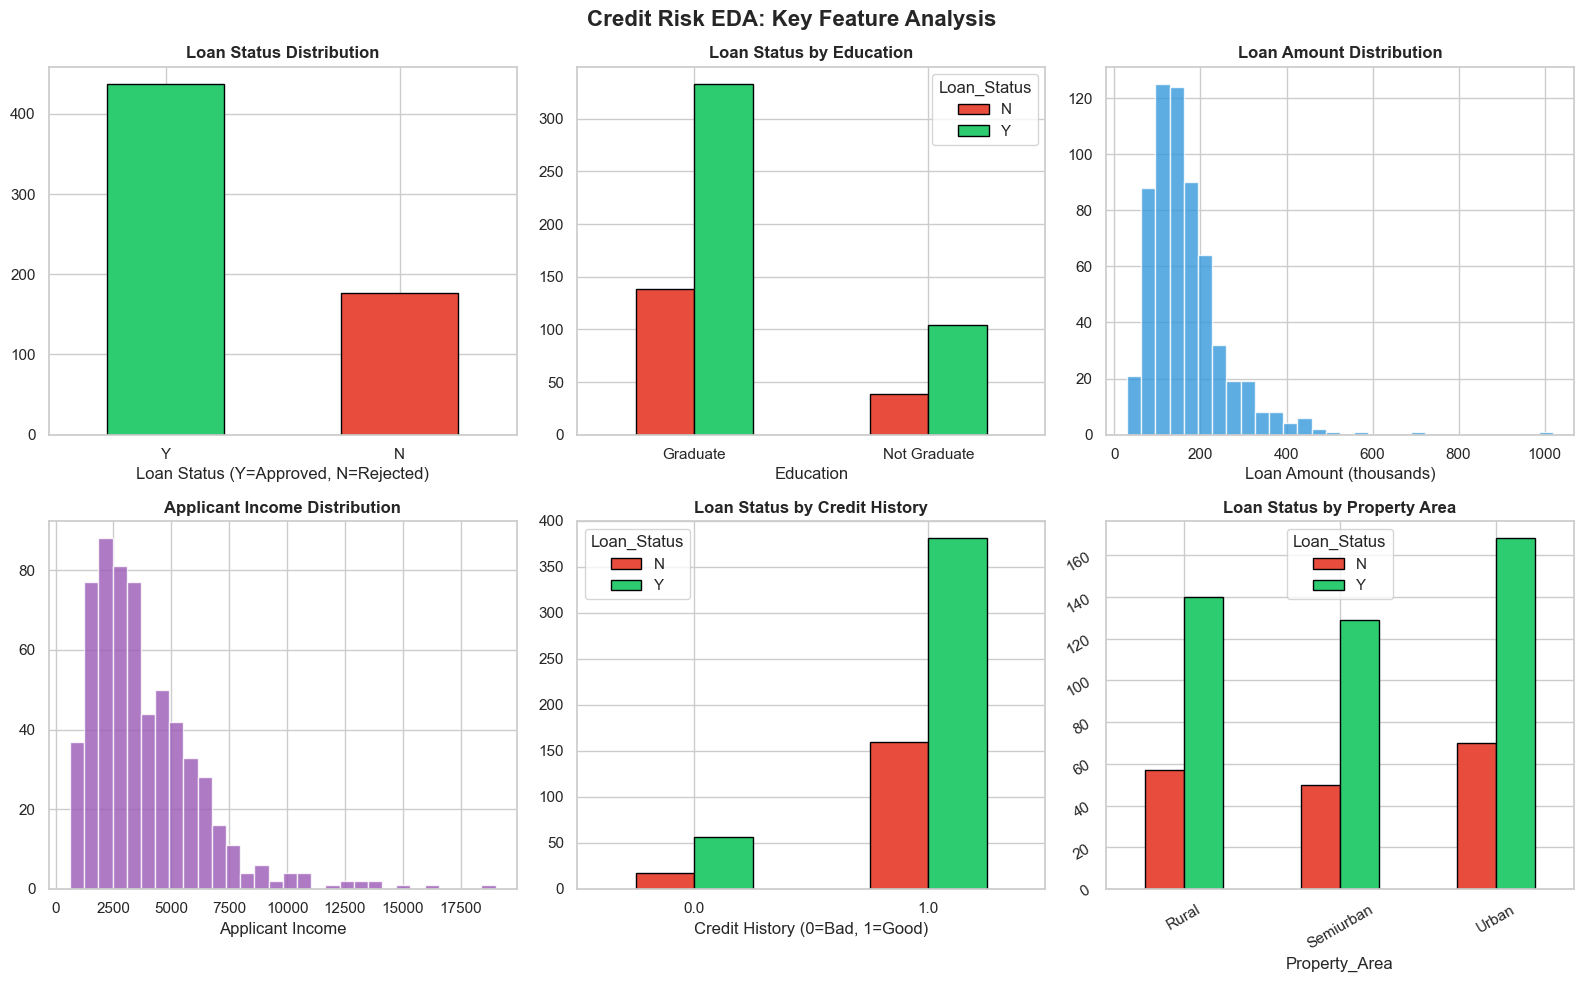

In [8]:
# Key feature visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Loan Status distribution
df['Loan_Status'].value_counts().plot(kind='bar', ax=axes[0,0], 
    color=['#2ECC71','#E74C3C'], edgecolor='black')
axes[0,0].set_title('Loan Status Distribution', fontweight='bold')
axes[0,0].set_xlabel('Loan Status (Y=Approved, N=Rejected)')
axes[0,0].tick_params(rotation=0)

# Loan Status by Education
pd.crosstab(df['Education'], df['Loan_Status']).plot(kind='bar', ax=axes[0,1],
    color=['#E74C3C','#2ECC71'], edgecolor='black')
axes[0,1].set_title('Loan Status by Education', fontweight='bold')
axes[0,1].tick_params(rotation=0)

# Loan Amount Distribution
axes[0,2].hist(df['LoanAmount'], bins=30, color='#3498DB', edgecolor='white', alpha=0.8)
axes[0,2].set_title('Loan Amount Distribution', fontweight='bold')
axes[0,2].set_xlabel('Loan Amount (thousands)')

# Applicant Income Distribution
axes[1,0].hist(df['ApplicantIncome'], bins=30, color='#9B59B6', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Applicant Income Distribution', fontweight='bold')
axes[1,0].set_xlabel('Applicant Income')

# Credit History vs Loan Status
pd.crosstab(df['Credit_History'], df['Loan_Status']).plot(kind='bar', ax=axes[1,1],
    color=['#E74C3C','#2ECC71'], edgecolor='black')
axes[1,1].set_title('Loan Status by Credit History', fontweight='bold')
axes[1,1].set_xlabel('Credit History (0=Bad, 1=Good)')
axes[1,1].tick_params(rotation=0)

# Property Area vs Loan Status
pd.crosstab(df['Property_Area'], df['Loan_Status']).plot(kind='bar', ax=axes[1,2],
    color=['#E74C3C','#2ECC71'], edgecolor='black')
axes[1,2].set_title('Loan Status by Property Area', fontweight='bold')
axes[1,2].tick_params(rotation=30)

plt.suptitle('Credit Risk EDA: Key Feature Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

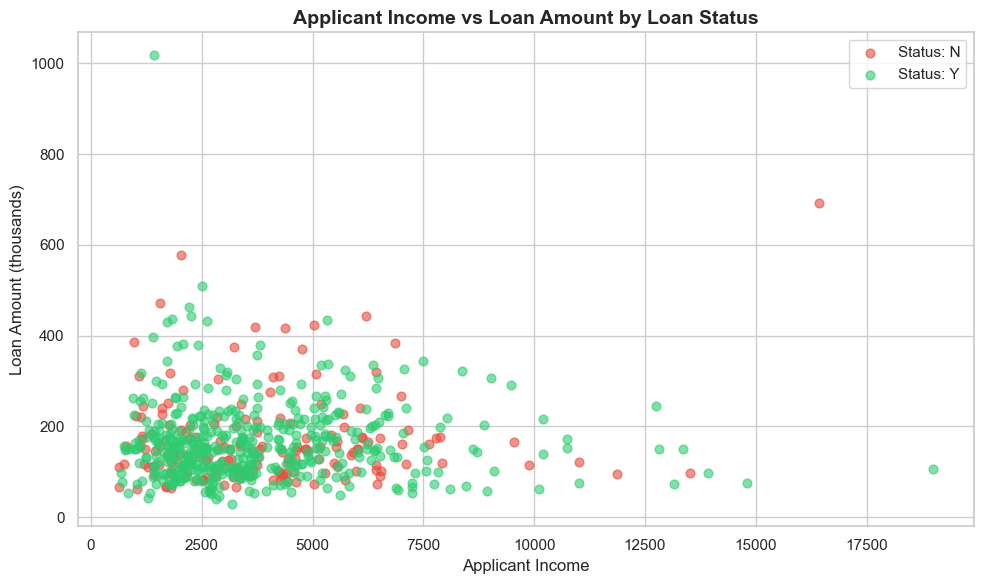

In [9]:
# Income vs Loan Amount scatter colored by approval
plt.figure(figsize=(10, 6))
colors = {'Y': '#2ECC71', 'N': '#E74C3C'}
for status, grp in df.groupby('Loan_Status'):
    plt.scatter(grp['ApplicantIncome'], grp['LoanAmount'],
                c=colors[status], label=f'Status: {status}', alpha=0.6, s=40)
plt.title('Applicant Income vs Loan Amount by Loan Status', fontsize=14, fontweight='bold')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount (thousands)')
plt.legend()
plt.tight_layout()
plt.savefig('income_vs_loan.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Engineering & Encoding

In [10]:
# Label encode all categorical columns
le = LabelEncoder()
df_model = df.copy()

# Drop Loan_ID (not useful for prediction)
df_model.drop('Loan_ID', axis=1, inplace=True)

# Encode categorical columns
cat_cols = ['Gender','Married','Dependents','Education','Self_Employed',
            'Property_Area','Loan_Status']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    print(f"  Encoded: {col}")

print("\nFirst 5 rows of encoded dataset:")
df_model.head()

  Encoded: Gender
  Encoded: Married
  Encoded: Dependents
  Encoded: Education
  Encoded: Self_Employed
  Encoded: Property_Area
  Encoded: Loan_Status

First 5 rows of encoded dataset:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,1429,1617.971602,190.3,360.0,1.0,2,1
1,1,1,2,0,0,1796,4344.460949,138.5,360.0,1.0,2,1
2,1,1,1,0,0,4710,2664.143573,205.2,360.0,1.0,2,1
3,1,1,3,0,1,1789,1412.763538,317.8,360.0,1.0,2,0
4,1,1,0,0,0,1826,2545.685695,132.0,360.0,1.0,0,1


## 7. Model Training

In [11]:
# Define features and target
X = df_model.drop('Loan_Status', axis=1)
y = df_model['Loan_Status']

print("Features:", X.columns.tolist())
print("Target: Loan_Status")

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']
Target: Loan_Status

Training set: 491 samples
Testing set:  123 samples


In [12]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")

Logistic Regression Accuracy: 71.54%


In [13]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_acc*100:.2f}%")

Decision Tree Accuracy: 70.73%


## 8. Model Evaluation

In [14]:
# Compare models
models = {'Logistic Regression': (lr_pred, lr_acc), 'Decision Tree': (dt_pred, dt_acc)}

for name, (pred, acc) in models.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy: {acc*100:.2f}%")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, pred, target_names=['Not Approved','Approved']))


  Logistic Regression
  Accuracy: 71.54%

  Classification Report:
              precision    recall  f1-score   support

Not Approved       0.00      0.00      0.00        35
    Approved       0.72      1.00      0.83        88

    accuracy                           0.72       123
   macro avg       0.36      0.50      0.42       123
weighted avg       0.51      0.72      0.60       123


  Decision Tree
  Accuracy: 70.73%

  Classification Report:
              precision    recall  f1-score   support

Not Approved       0.33      0.03      0.05        35
    Approved       0.72      0.98      0.83        88

    accuracy                           0.71       123
   macro avg       0.53      0.50      0.44       123
weighted avg       0.61      0.71      0.61       123



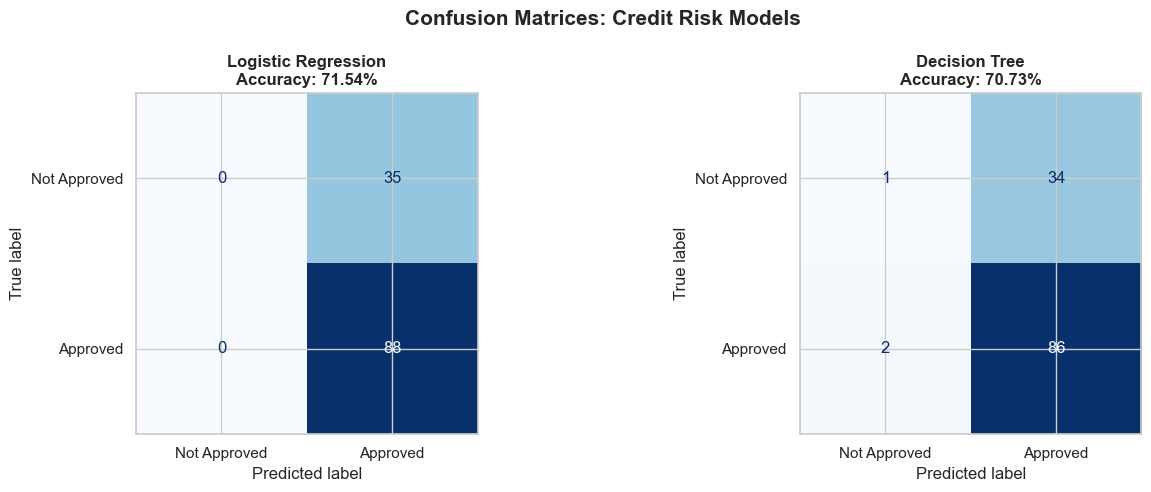

In [15]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, (pred, acc)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Not Approved', 'Approved'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontweight='bold')

plt.suptitle('Confusion Matrices: Credit Risk Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

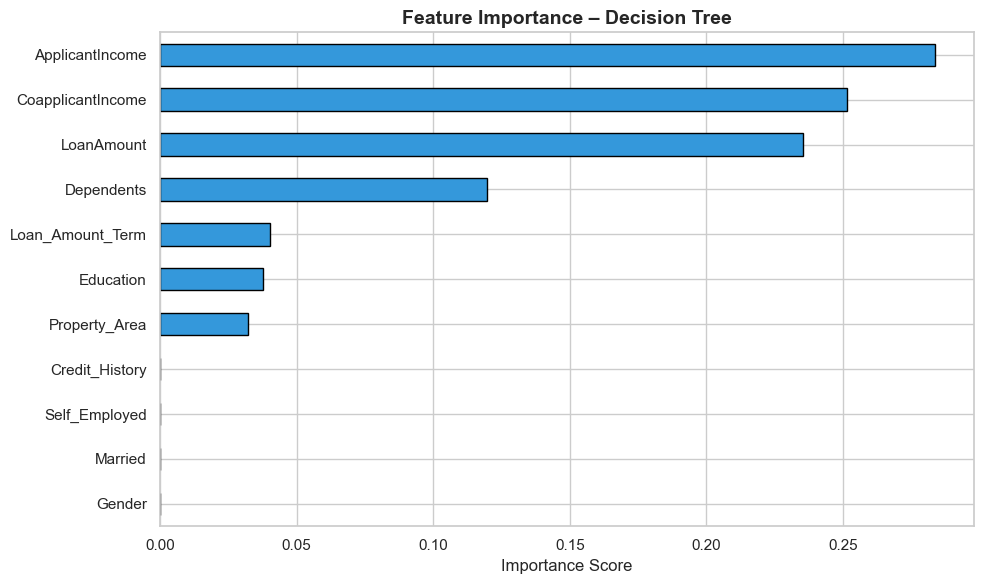

In [16]:
# Feature importance from Decision Tree
feature_importance = pd.Series(dt_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='#3498DB', edgecolor='black')
plt.title('Feature Importance – Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Conclusion

### Key Insights:

1. **Credit History is the Most Important Feature**: Applicants with a good credit history (1.0) have significantly higher loan approval rates.

2. **Education Matters**: Graduate applicants have higher approval rates, suggesting educational background influences creditworthiness.

3. **Income Distribution is Skewed**: Most applicants have lower incomes with a few high earners — a common real-world pattern in financial datasets.

4. **Model Performance**: Both Logistic Regression and Decision Tree achieve good accuracy. Credit history, loan amount, and income are the strongest predictors.

5. **Class Imbalance**: The dataset is slightly imbalanced (~69% approved), which is realistic — banks approve more loans than they reject.

### Skills Applied:
- Data cleaning and handling missing values (mode/median imputation)
- Exploratory Data Analysis with targeted visualizations
- Binary classification using Logistic Regression and Decision Tree
- Model evaluation using accuracy, confusion matrix, and classification report
